# 30s optical potential calibration

This notebook demonstrates a small end-to-end adaptive Metropolis calibration
of an elastic differential cross section model using **mock data** .


In [1]:
import jitr
import matplotlib.pyplot as plt
import numpy as np
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from scipy import stats
import corner

import rxmc
from rxmc.params import Parameter

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## Reaction and optical model


In [2]:
Ca40 = (40, 20)
neutron = (1, 0)
E_lab = 14.1

rxn = jitr.reactions.ElasticReaction(target=Ca40, projectile=neutron)

mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def central_potential(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) + (
        4j * ad * Wd
    ) * woods_saxon_prime_safe(r, Rd, ad)


def spin_orbit_potential(r, Vso, Wso, Rso, aso):
    return (Vso + 1j * Wso) * mso**2 * thomas_safe(r, Rso, aso)

R  = 1.2 * 40**(1/3)
fixed_spin_orbit = (6.0, -3, R  , 0.45)

def extract_params(ws, *x):
    Vv, Wv, Rv, av, Wd, Rd, ad = x
    central_params = (Vv, Wv, Rv, av, Wd, Rd, ad)
    return central_params, fixed_spin_orbit


params = [
    Parameter("Vv", unit="MeV"), 
    Parameter("Wv", unit="MeV"),
    Parameter("Rv", unit="fm"),
    Parameter("av", unit="fm"),
    Parameter("Wd", unit="MeV"),
    Parameter("Rd", unit="fm"),
    Parameter("ad", unit="fm"),

]

omp = rxmc.elastic_diffxs_model.ElasticDifferentialXSModel(
    "dXS/dA",
    interaction_central=central_potential,
    interaction_spin_orbit=spin_orbit_potential,
    calculate_interaction_from_params=extract_params,
    params=params,
    model_name="minimal_elastic_demo",
)

## Generate mock data and construct the observation directly

The key API change demonstrated here is that we can create an
`ElasticDifferentialXSObservation` directly from arrays and metadata, without
building an `exfor_tools.Distribution` object first.


In [3]:
angles_deg = np.linspace(2.0, 160.0, 28)
true_params = np.array([48.0, 3.5, 1.1*40**(1/3), 0.7, 21, 1.2*40**(1/3), 0.5])

template_obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
    x=angles_deg,
    y=np.ones_like(angles_deg, dtype=float),
    Elab=E_lab,
    reaction=rxn,
    quantity="dXS/dA",
    measurement_quantity="dXS/dA",
    y_units="barn / steradian",
    dataset_label="template",
)

y_true = omp.evaluate(template_obs, *true_params)

rng = np.random.default_rng(42)
y_stat_err = 0.2 * np.maximum(y_true, 1e-4)
y_mock = np.clip(y_true + rng.normal(scale=y_stat_err*1.3), 1e-6, None)

obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
    x=angles_deg,
    y=y_mock,
    Elab=E_lab,
    reaction=rxn,
    quantity="dXS/dA",
    measurement_quantity="dXS/dA",
    y_units="barn / steradian",
    y_stat_err=y_stat_err,
    dataset_label="mock elastic dataset",
)

Text(0.5, 1.0, 'Mock differential cross section data for n + $^{40}$Ca')

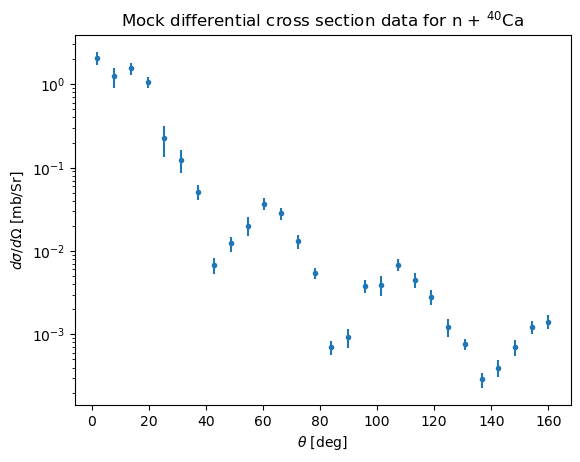

In [4]:
plt.errorbar(np.rad2deg(obs.x), obs.y, obs.y_stat_err, linestyle="none", marker='.')
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [mb/Sr]")
plt.yscale("log")
plt.title("Mock differential cross section data for n + $^{40}$Ca")

## Set up the inference problem


In [5]:
constraint = rxmc.constraint.Constraint(
    observations=[obs],
    physical_model=omp,
    likelihood_model=rxmc.likelihood_model.LikelihoodModel(),
)
evidence = rxmc.evidence.Evidence(constraints=[constraint])

prior_mean = np.array([50.0, 3,1.2*40**(1/3), 0.65, 18,1.2*40**(1/3), 0.65])
prior_cov = np.diag([7, 7, 0.2, 0.2, 10, 0.2, 0.2 ])**2
prior = stats.multivariate_normal(mean=prior_mean, cov=prior_cov)

walker = rxmc.walker.Walker(
    model_sampler=rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=omp.params,
        prior=prior,
        starting_location=prior_mean,
        initial_proposal_cov=prior_cov/100,
    ),
    evidence=evidence,
    rng=np.random.default_rng(7),
)

In [6]:
%%time
walker.walk(n_steps=20000, burnin=1000, batch_size=1000, verbose=True)
samples = walker.model_sampler.chain[40:]
acceptance_fraction = walker.model_sampler.overall_acceptance_fraction()
acceptance_fraction

Burn-in batch 1/1 completed, 1000 steps.
Batch: 1/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.172
Batch: 2/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.181
Batch: 3/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.199
Batch: 4/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.202
Batch: 5/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.212
Batch: 6/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.269
Batch: 7/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.250
Batch: 8/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.210
Batch: 9/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.203
Batch: 10/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.181
Batch: 11/20 completed, 1000 steps. 
  Model parameter acceptance fraction: 0.225
Batch: 12/20 completed, 1000 steps. 
  Model parameter acceptance 

0.20535

## Posterior summary and predictive band


In [7]:
posterior_mean = np.mean(samples, axis=0)
posterior_std = np.std(samples, axis=0)
draw_indices = np.linspace(
    0, samples.shape[0] - 1, min(60, samples.shape[0]), dtype=int
)
posterior_draws = samples[draw_indices]
y_draws = np.array([omp.visualizable_model_prediction(obs, *draw) for draw in posterior_draws])
y_mean = np.mean(y_draws, axis=0)
y_low, y_high = np.percentile(y_draws, [5, 95], axis=0)
y_true = omp.visualizable_model_prediction(obs, *true_params)
for i in range(len(params)):
    print(f"{params[i].name}: truth={true_params[i]:1.2f} mean={posterior_mean[i]:1.2f}, std={posterior_std[i]:1.2f}")

Vv: truth=48.00 mean=43.94, std=2.62
Wv: truth=3.50 mean=4.73, std=2.03
Rv: truth=3.76 mean=3.93, std=0.15
av: truth=0.70 mean=0.64, std=0.05
Wd: truth=21.00 mean=18.74, std=2.93
Rd: truth=4.10 mean=4.10, std=0.08
ad: truth=0.50 mean=0.50, std=0.05


Text(0.5, 0, '$i$')

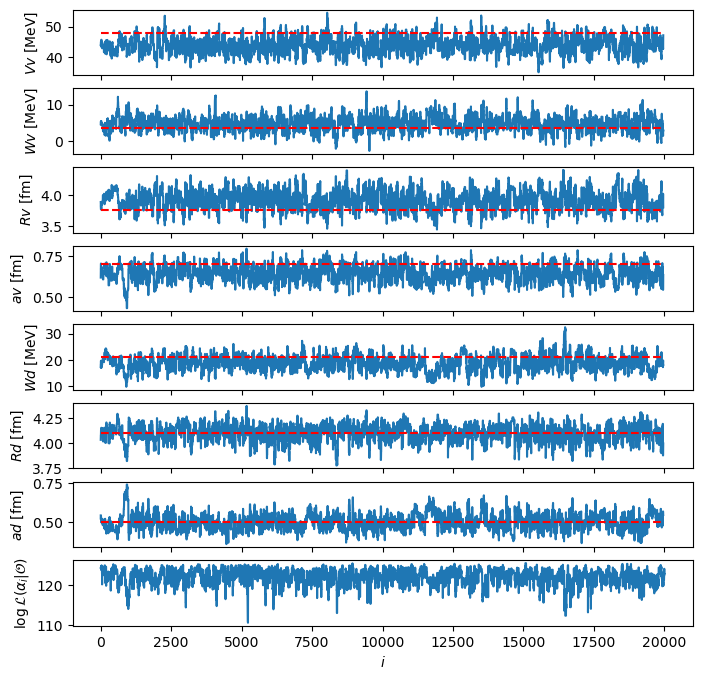

In [8]:
fig, axes = plt.subplots(samples.shape[1] + 1, 1, figsize=(8, 8), sharex=True)
logp = walker.model_sampler.logp_chain
for i in range(samples.shape[1]):
    axes[i].plot(samples[:, i])
    axes[i].set_ylabel(f"${omp.params[i].latex_name}$ [{omp.params[i].unit}]")
    true_value = true_params[i]
    axes[i].hlines(true_value, 0, len(samples), "r", linestyle="--")
axes[-1].plot(logp)
axes[-1].set_ylabel(r"$\log{\mathcal{L}(\alpha_i | \mathcal{O})}$")

axes[-1].set_xlabel(r"$i$")


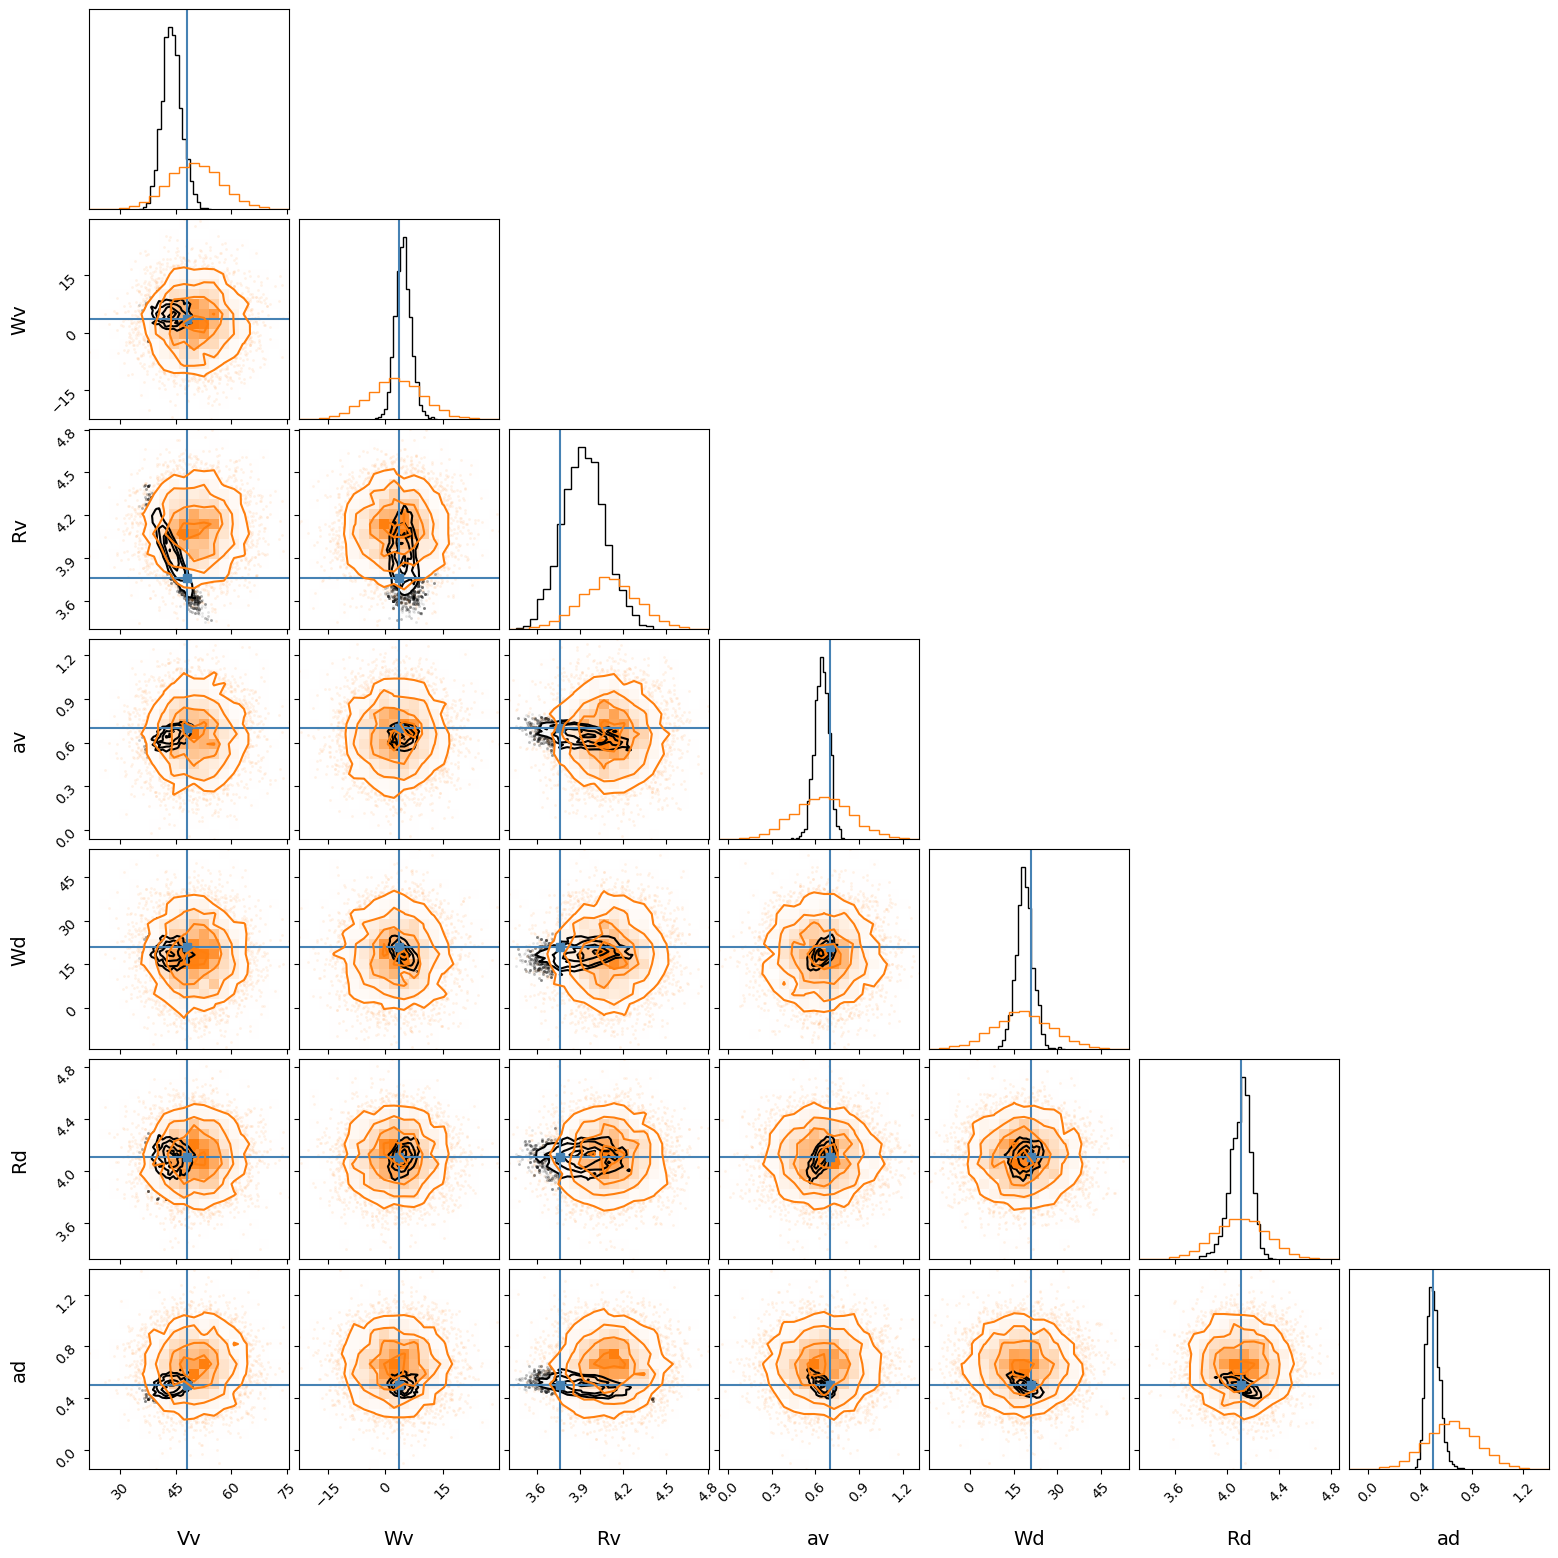

In [9]:
fig = corner.corner(
    samples,
    labels=[p.name for p in omp.params],
    truths=true_params,
    label_kwargs={"fontsize": 14},
)
_ = corner.corner(prior.rvs(5000), fig=fig, color='tab:orange')


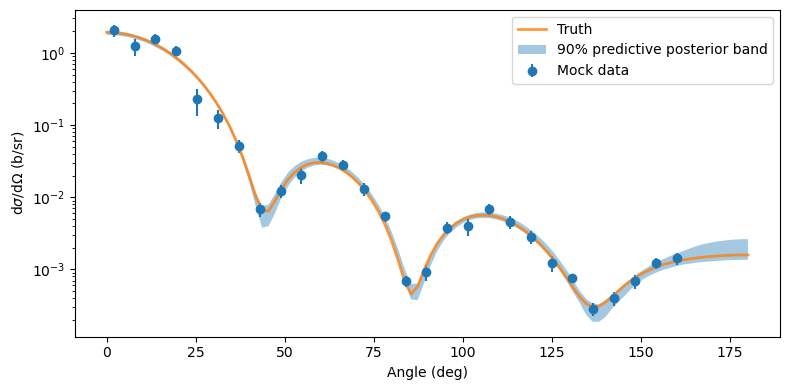

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

angles_plot = np.rad2deg(obs.visualization_workspace.angles)
ax.errorbar(np.rad2deg(obs.x), obs.y, yerr=obs.y_stat_err, fmt="o", label="Mock data")
ax.plot(angles_plot, y_true,label="Truth", linewidth=2, alpha=0.8)
ax.fill_between(angles_plot, y_low, y_high, alpha=0.4, label="90% predictive posterior band")
ax.set_xlabel("Angle (deg)")
ax.set_ylabel("d$\\sigma$/d$\\Omega$ (b/sr)")
ax.legend()
ax.set_yscale("log")
fig.tight_layout()

Note that the predictive posterior has excellent coverage of the training data, even though the parameter inference was not perfect. One must be wary of infering parameters from optical potentials, as multiple different sets of parameter values can produce the same cross section! 